### 🤖 What is ReAct?
ReAct (Reasoning + Acting) is a framework where an LLM:

- Reasons step-by-step (e.g. decomposes questions, makes decisions)

- Acts by calling tools like search, calculators, or retrievers

This makes it perfect for Agentic RAG:
✅ Think → Retrieve → Observe → Reflect → Final Answer

In [19]:
import os
# from langchain.agents import create_agent
# from langgraph.prebuilt import create_react_agent
from langchain_classic.agents import Tool
from langchain_classic.tools import WikipediaQueryRun
from langchain_classic.utilities import WikipediaAPIWrapper
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings
from langchain_community.document_loaders import WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import END, StateGraph,START
from langgraph.graph import StateGraph
from typing import Annotated, TypedDict, Sequence
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
from langgraph.graph.message import add_messages

In [20]:
# --------------------------
# 1. Create Retriever Tool
# --------------------------
from langchain_ollama import OllamaEmbeddings
# Load content from blog
docs = WebBaseLoader("https://lilianweng.github.io/posts/2023-06-23-agent/").load()
splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
chunks = splitter.split_documents(docs)

# embedding = OpenAIEmbeddings()
embedding = OllamaEmbeddings(model="llama3.2:latest")
vectorstore = FAISS.from_documents(chunks, embedding)
retriever = vectorstore.as_retriever()

In [21]:
retriever.invoke("what are autonomous agents")

[Document(id='2039b78c-7539-43ff-a227-867d43b70a46', metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'title': "LLM Powered Autonomous Agents | Lil'Log", 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, 

In [22]:
def retriever_tool_func(query: str) -> str:
    print("📚 Using RAGRetriever tool")
    docs = retriever.invoke(query)
    return "\n".join([doc.page_content for doc in docs])

In [23]:
retriever_tool_func("what are autonomous agents")

📚 Using RAGRetriever tool


'Memory\n\nShort-term memory: I would consider all the in-context learning (See Prompt Engineering) as utilizing short-term memory of the model to learn.\nLong-term memory: This provides the agent with the capability to retain and recall (infinite) information over extended periods, often by leveraging an external vector store and fast retrieval.\n\n\nTool use\nPrompt LM with 100 most recent observations and to generate 3 most salient high-level questions given a set of observations/statements. Then ask LM to answer those questions.\n\n\nPlanning & Reacting: translate the reflections and the environment information into actions\nAPI-Bank (Li et al. 2023) is a benchmark for evaluating the performance of tool-augmented LLMs. It contains 53 commonly used API tools, a complete tool-augmented LLM workflow, and 264 annotated dialogues that involve 568 API calls. The selection of APIs is quite diverse, including search engines, calculator, calendar queries, smart home control, schedule manage

In [24]:
retriever_tool=Tool(
    name="RAGRetriever",
    description="Use this tool to fetch relevant knowledge base info",
    func=retriever_tool_func
)
retriever_tool
print(retriever_tool.name)

RAGRetriever


In [25]:
wiki_tool=WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper())
wiki_tool

WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper(wiki_client=<module 'wikipedia' from 'c:\\Users\\ArnavBhatia\\anaconda3\\envs\\llms\\Lib\\site-packages\\wikipedia\\__init__.py'>, top_k_results=3, lang='en', load_all_available_meta=False, doc_content_chars_max=4000))

In [26]:
from langchain.chat_models import init_chat_model
from langgraph.prebuilt import create_react_agent
tools=[retriever_tool,wiki_tool]
react_node=create_react_agent(tools=tools, model=init_chat_model("ollama:llama3.2:latest"))

C:\Users\ArnavBhatia\AppData\Local\Temp\ipykernel_37516\2217523955.py:4: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  react_node=create_react_agent(tools=tools, model=init_chat_model("ollama:llama3.2:latest"))


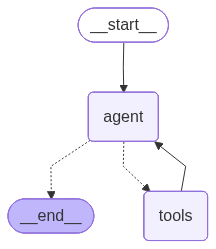

In [27]:
from IPython.display import Image,display
display(Image(react_node.get_graph().draw_mermaid_png()))

Agent State

In [28]:
from pydantic import BaseModel
class AgentState(TypedDict):
    messages:Annotated[Sequence[BaseMessage],add_messages]

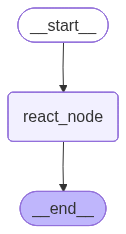

In [29]:
builder=StateGraph(AgentState)

builder.add_node("react_node",react_node)
builder.set_entry_point("react_node")
builder.add_edge("react_node",END)

graph=builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [30]:
# --------------------------
# 5. Run the ReAct Agent
# --------------------------

if __name__ == "__main__":
    user_query = "What is an agent loop and how does Wikipedia describe autonomous agents?"
    state = {"messages": [HumanMessage(content=user_query)]}
    result = graph.invoke(state)

    print("\n✅ Final Answer:\n", result["messages"][-1].content)


✅ Final Answer:
 An agent loop refers to a situation where an autonomous agent, such as a machine learning model or a software program, becomes stuck in a repetitive cycle of actions, often referred to as a "loop" or "cycle." This can occur when the agent's goal is not clearly defined or when it encounters an unexpected obstacle that prevents it from making progress.

In the context of autonomous agents, agent loops can be problematic because they can lead to inefficient or even harmful behavior. For example, if an agent is tasked with completing a complex task, such as navigating a maze, and instead gets stuck in a repetitive cycle of moving forward and backward, it may not make progress towards its goal.

Autonomous agents like AutoGPT, which uses OpenAI's large language models to achieve goals specified by users, can also get stuck in agent loops. These loops can be caused by the agent's inability to effectively navigate its environment or by the limitations of its programming or t